In [1]:
from collections import Counter

import pandas as pd
from scipy.stats import random_table

data = pd.read_csv("data/data.csv")

In [2]:
df = data.drop(columns=["date", "country", "street"])

In [3]:
print(df.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')


In [4]:
df.shape

(4600, 15)

In [5]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
statezip         0
dtype: int64

In [6]:
df['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
 13  city           4600 non-null   object 
 14  statezip       4600 non-null   object 
dtypes: float64(4), int64(9), object(2)
memory usage: 539.2+ KB


In [8]:
new_df = df[df['price'] != 0]

In [9]:
new_df.shape

(4551, 15)

In [10]:
new_df['price'].min()

7800.0

In [11]:
new_df['price'].describe()

count    4.551000e+03
mean     5.579059e+05
std      5.639299e+05
min      7.800000e+03
25%      3.262643e+05
50%      4.650000e+05
75%      6.575000e+05
max      2.659000e+07
Name: price, dtype: float64

In [12]:
new_df = new_df[new_df["price"] <= new_df['price'].quantile(0.99)]

In [13]:
new_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.505000e+03,4505.000000,4505.000000,4505.000000,4.505000e+03,4505.000000,4505.000000,4505.000000,4505.000000,4505.000000,4505.000000,4505.000000,4505.000000
mean,5.287007e+05,3.384684,2.138402,2102.817092,1.473333e+04,1.509101,0.004883,0.220422,3.448613,1800.556271,302.260821,1970.793119,808.854384
std,2.908604e+05,0.898284,0.748827,885.611935,3.582477e+04,0.538200,0.069719,0.737856,0.673719,815.193614,444.803169,29.717405,979.481886
min,7.800000e+03,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.250000e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1180.000000,0.000000,1951.000000,0.000000
50%,4.610000e+05,3.000000,2.250000,1960.000000,7.642000e+03,1.500000,0.000000,0.000000,3.000000,1580.000000,0.000000,1976.000000,0.000000
75%,6.500000e+05,4.000000,2.500000,2590.000000,1.086000e+04,2.000000,0.000000,0.000000,4.000000,2280.000000,600.000000,1997.000000,1999.000000
max,2.005000e+06,9.000000,5.750000,7320.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,7320.000000,2850.000000,2014.000000,2014.000000


In [14]:
new_df.shape

(4505, 15)

In [15]:
import matplotlib.pyplot as plt

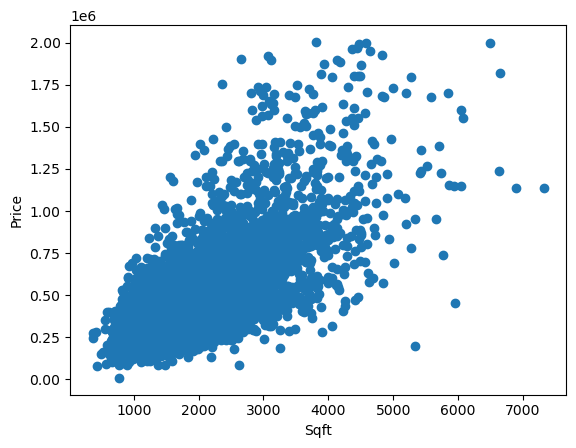

In [16]:
plt.scatter(new_df['sqft_living'], new_df['price'])
plt.xlabel('Sqft')
plt.ylabel('Price')
plt.show()

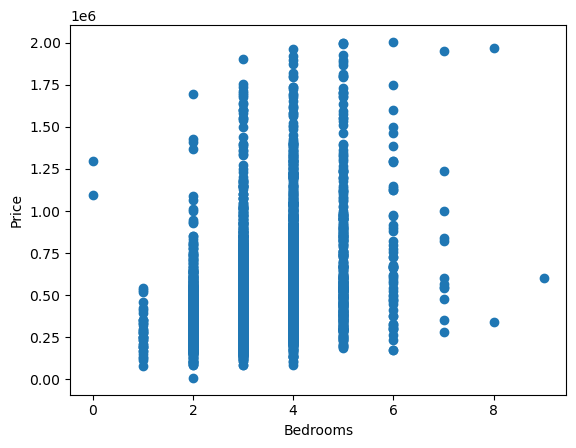

In [17]:
plt.scatter(new_df['bedrooms'], new_df['price'])
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

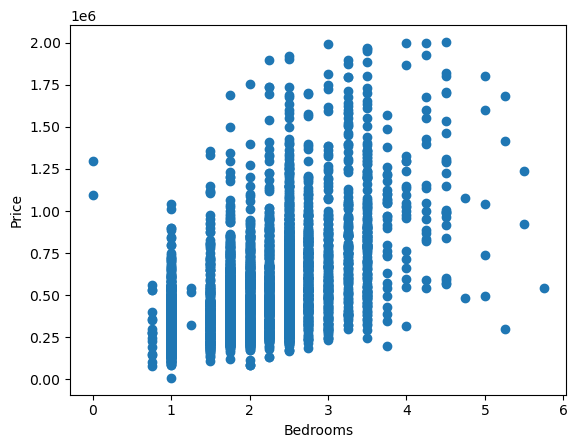

In [18]:
plt.scatter(new_df['bathrooms'], new_df['price'])
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

In [19]:
cities = new_df['statezip'].unique().tolist()

In [20]:
len(cities)

77

In [21]:
new_df = new_df.drop('city', axis=1)

In [22]:
new_df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'statezip'],
      dtype='object')

In [23]:
df_encoded = pd.get_dummies(new_df, columns=['statezip'], drop_first=True, dtype="int")
print(df_encoded.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'statezip_WA 98002', 'statezip_WA 98003',
       'statezip_WA 98004', 'statezip_WA 98005', 'statezip_WA 98006',
       'statezip_WA 98007', 'statezip_WA 98008', 'statezip_WA 98010',
       'statezip_WA 98011', 'statezip_WA 98014', 'statezip_WA 98019',
       'statezip_WA 98022', 'statezip_WA 98023', 'statezip_WA 98024',
       'statezip_WA 98027', 'statezip_WA 98028', 'statezip_WA 98029',
       'statezip_WA 98030', 'statezip_WA 98031', 'statezip_WA 98032',
       'statezip_WA 98033', 'statezip_WA 98034', 'statezip_WA 98038',
       'statezip_WA 98039', 'statezip_WA 98040', 'statezip_WA 98042',
       'statezip_WA 98045', 'statezip_WA 98047', 'statezip_WA 98050',
       'statezip_WA 98051', 'statezip_WA 98052', 'statezip_WA 98053',
       'statezip_WA 98055', 'statezip_WA 98056', 'statezip_WA 98057',
  

In [24]:
df_encoded.shape

(4505, 89)

In [25]:
x = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [27]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [28]:
y_pred = regressor.predict(x_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(mae)

93298.48540434518


In [29]:
error = (mae/df_encoded['price'].mean())*100

In [30]:
print(error)

17.646750086632345


In [31]:
df_encoded[df_encoded['sqft_above'] + df_encoded['sqft_basement'] == df_encoded['sqft_living']].shape

(4505, 89)

In [32]:
temp = df_encoded['yr_renovated'].tolist()

In [33]:
counts = {}

for item in temp:
    counts[item] = counts.get(item, 0) + 1

In [34]:
print(counts)

{2005: 93, 0: 2678, 1992: 32, 1994: 56, 2010: 30, 1988: 42, 2009: 106, 1969: 11, 2000: 168, 1979: 30, 1989: 54, 2014: 71, 1999: 39, 2003: 148, 1983: 40, 1997: 28, 1912: 33, 1923: 54, 1954: 8, 2011: 54, 2001: 104, 2013: 61, 2006: 66, 1972: 17, 1985: 29, 1998: 39, 2004: 77, 1958: 5, 2008: 45, 1970: 9, 1982: 22, 1986: 5, 1996: 20, 2002: 39, 1971: 5, 1990: 16, 1956: 15, 1945: 7, 1984: 9, 2012: 45, 1993: 38, 2007: 6, 1981: 1, 1974: 6, 1963: 12, 1968: 9, 1995: 2, 1934: 6, 1953: 1, 1966: 1, 1955: 2, 1987: 1, 1960: 1, 1978: 3, 1980: 2, 1948: 1, 1991: 1, 1913: 1, 1977: 1}


In [35]:
def convert_renovated(value):
    if value == 0:
        return 0
    else:
        return 1

df_encoded["renovated"] = df_encoded['yr_renovated'].apply(convert_renovated)

In [36]:
df_encoded.drop(columns=["yr_renovated", "sqft_above", "sqft_basement"], inplace=True)

In [37]:
x = df_encoded.drop('price', axis=1)
y = df_encoded['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [38]:
y_pred = regressor.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
Mae = []
Mae.append(mae)
print(mae)

87133.50576591535


In [39]:
87133.50576591535/df_encoded['price'].mean()

np.float64(0.16480687695618637)

In [40]:
from sklearn.tree import DecisionTreeRegressor
DTregressor = DecisionTreeRegressor()
DTregressor.fit(x_train, y_train)
y_pred = DTregressor.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
Mae.append(mae)
print(mae)

139326.12211575804


In [41]:
from sklearn.ensemble import RandomForestRegressor
randomregressor = RandomForestRegressor()
randomregressor.fit(x_train, y_train)
y_pred = randomregressor.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
Mae.append(mae)
print(mae)

101681.98489934712


In [42]:
coef_df = pd.DataFrame({
    'Features': x.columns,
    'coefficients': regressor.coef_,
})

In [43]:
x.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'yr_built', 'statezip_WA 98002',
       'statezip_WA 98003', 'statezip_WA 98004', 'statezip_WA 98005',
       'statezip_WA 98006', 'statezip_WA 98007', 'statezip_WA 98008',
       'statezip_WA 98010', 'statezip_WA 98011', 'statezip_WA 98014',
       'statezip_WA 98019', 'statezip_WA 98022', 'statezip_WA 98023',
       'statezip_WA 98024', 'statezip_WA 98027', 'statezip_WA 98028',
       'statezip_WA 98029', 'statezip_WA 98030', 'statezip_WA 98031',
       'statezip_WA 98032', 'statezip_WA 98033', 'statezip_WA 98034',
       'statezip_WA 98038', 'statezip_WA 98039', 'statezip_WA 98040',
       'statezip_WA 98042', 'statezip_WA 98045', 'statezip_WA 98047',
       'statezip_WA 98050', 'statezip_WA 98051', 'statezip_WA 98052',
       'statezip_WA 98053', 'statezip_WA 98055', 'statezip_WA 98056',
       'statezip_WA 98057', 'statezip_WA 98058', 'statezip_WA 98059',
       'statezip

In [44]:
coef_df_new = coef_df[:9]

In [45]:
coef_df_new = pd.concat([coef_df_new, coef_df.iloc[[-1]]])

In [46]:
coef_df_new

,Features,coefficients
0,bedrooms,-18750.239550
1,bathrooms,22676.982510
2,sqft_living,178.891806
3,sqft_lot,0.162805
4,floors,19057.366196
5,waterfront,97951.795303
6,view,56026.792332
7,condition,21798.501505
8,yr_built,-287.864624
85,renovated,8427.504209


In [47]:
coef_df_new = coef_df_new.sort_values(by='coefficients', key = abs, ascending=False)

In [48]:
coef_df_new

,Features,coefficients
5,waterfront,97951.795303
6,view,56026.792332
1,bathrooms,22676.982510
7,condition,21798.501505
4,floors,19057.366196
0,bedrooms,-18750.239550
85,renovated,8427.504209
8,yr_built,-287.864624
2,sqft_living,178.891806
3,sqft_lot,0.162805


In [49]:
coef_df_sorted = coef_df.sort_values(by='coefficients', key = abs, ascending=False)

In [50]:
coef_df_sorted

,Features,coefficients
11,statezip_WA 98004,7.024317e+05
32,statezip_WA 98039,6.009982e+05
61,statezip_WA 98112,5.971516e+05
60,statezip_WA 98109,5.664932e+05
56,statezip_WA 98105,5.256811e+05
...,...,...
34,statezip_WA 98042,-4.609758e+02
8,yr_built,-2.878646e+02
2,sqft_living,1.788918e+02
3,sqft_lot,1.628053e-01


In [51]:
mae_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'Mean Absolute Error': Mae,
})

In [52]:
mae_df

,Model,Mean Absolute Error
0,Linear Regression,87133.505766
1,Decision Tree Regressor,139326.122116
2,Random Forest Regressor,101681.984899


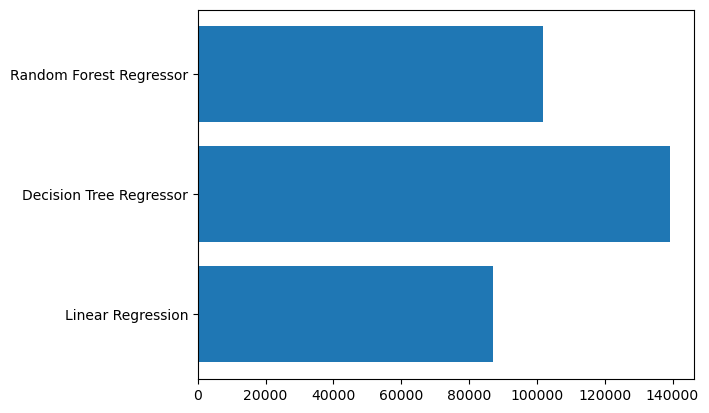

In [53]:
plt.barh(mae_df['Model'], mae_df['Mean Absolute Error'])
plt.show()

In [54]:
from sklearn.metrics import r2_score, root_mean_squared_error
y_pred = regressor.predict(x_test)
print("R2 Score: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

R2 Score:  0.7786869152713466
RMSE:  131305.75130669045


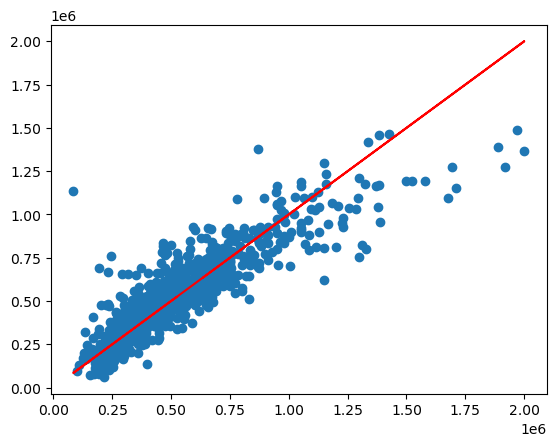

In [55]:
plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='red')
plt.show()

In [56]:
x = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
import numpy as np
y_train_log = np.log1p(y_train)
model = LinearRegression()
model.fit(x_train, y_train_log)

LinearRegression()

In [59]:
y_pred_log = model.predict(x_test)
y_pred = np.expm1(y_pred_log)
print("R2 Score: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))

R2 Score:  0.7718602546026962
RMSE:  133315.51032779008
MAE:  84608.87619774319


In [67]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')